# FARS 2023 — Modeling Notebook
**ADTA 5940 | Fatal Crash Analysis**

This notebook covers the full modeling pipeline for two binary classification targets:
- `IS_ALCOHOL_IMPAIRED` — RQ1 & RQ2
- `IS_SPEEDING` — RQ3 & RQ4

Three models are trained per target: Logistic Regression, Random Forest, and XGBoost.  
SHAP values are computed on the XGBoost models for explainability.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 2. Data Loading & Merging

Replicates the merge strategy from the EDA notebook:
1. Filter `person.csv` to drivers only (`PER_TYP == 1`)
2. Derive binary targets (`IS_ALCOHOL_IMPAIRED`, `IS_SPEEDING`)
3. Inner join drivers → vehicles on `ST_CASE + VEH_NO`
4. Left join → accidents on `ST_CASE`

In [2]:
# --- Load raw files ---
accident = pd.read_csv('accident.csv', low_memory=False)
vehicle  = pd.read_csv('vehicle.csv',  low_memory=False)
person   = pd.read_csv('person.csv',   low_memory=False)

print(f'Accident : {accident.shape}')
print(f'Vehicle  : {vehicle.shape}')
print(f'Person   : {person.shape}')

Accident : (37654, 80)
Vehicle  : (58319, 203)
Person   : (92400, 126)


In [ ]:
# --- Filter to drivers only ---
drivers = person[person['PER_TYP'] == 1].copy()
print(f'Drivers  : {drivers.shape[0]:,} rows')

# --- Derive IS_ALCOHOL_IMPAIRED ---
# BAC >= 8 (i.e. 0.08 g/dL) = impaired; below = not impaired; unknown (97/98/99 codes) = NaN
drivers['IS_ALCOHOL_IMPAIRED'] = drivers['ALC_RES'].apply(
    lambda x: np.nan if pd.isnull(x) or x in [995, 996, 997, 998, 999]
    else (1 if x >= 8 else 0)
)

# --- Derive IS_SPEEDING (from vehicle file — will be joined below) ---
# Codes 2-5 = speeding-related; 0 = not; 8/9 = unknown
vehicle['IS_SPEEDING'] = vehicle['SPEEDREL'].apply(
    lambda x: 1 if x in [2, 3, 4, 5] else (0 if x in [0, 1] else np.nan)
    if pd.notnull(x) else np.nan
)

print(f"Alcohol impaired (of tested): {drivers['IS_ALCOHOL_IMPAIRED'].mean():.1%}")
print(f"Speeding (of valid):          {vehicle['IS_SPEEDING'].mean():.1%}")

Drivers  : 57,939 rows
Alcohol impaired (of tested): 76.6%
Speeding (of valid):          19.7%


In [4]:
# Select ONLY the columns we need from person — prevents all _x/_y collisions
# person shares many column names with vehicle and accident (STATE, HOUR, BODY_TYP, etc.)
PERSON_KEEP = ['ST_CASE', 'VEH_NO', 'AGE', 'SEX', 'ALC_RES', 'IS_ALCOHOL_IMPAIRED']
drivers_slim = drivers[PERSON_KEEP]

# --- Inner join drivers_slim + vehicle ---
df = drivers_slim.merge(
    vehicle[[
        'ST_CASE', 'VEH_NO', 'IS_SPEEDING',
        'BODY_TYP', 'SPEEDREL', 'VTRAFWAY', 'VSPD_LIM',
        'VALIGN', 'VPROFILE', 'VSURCOND', 'VNUM_LAN',
        'PREV_ACC', 'PREV_DWI', 'PREV_SPD', 'PREV_OTH',
        'DR_DRINK', 'TRAV_SP', 'ROLLOVER',
        'HOUR', 'MONTH'
    ]],
    on=['ST_CASE', 'VEH_NO'],
    how='inner'
)

# --- Left join + accident context ---
df = df.merge(
    accident[[
        'ST_CASE', 'STATE', 'DAY_WEEK',
        'RUR_URB', 'FUNC_SYS', 'TYP_INT', 'REL_ROAD',
        'LGT_COND', 'WEATHER', 'WRK_ZONE',
        'RELJCT1', 'RELJCT2', 'MAN_COLL'
    ]],
    on='ST_CASE',
    how='left'
)

print(f'Master dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {sorted(df.columns.tolist())}')

Master dataset: 57,939 rows x 36 columns
Columns: ['AGE', 'ALC_RES', 'BODY_TYP', 'DAY_WEEK', 'DR_DRINK', 'FUNC_SYS', 'HOUR', 'IS_ALCOHOL_IMPAIRED', 'IS_SPEEDING', 'LGT_COND', 'MAN_COLL', 'MONTH', 'PREV_ACC', 'PREV_DWI', 'PREV_OTH', 'PREV_SPD', 'RELJCT1', 'RELJCT2', 'REL_ROAD', 'ROLLOVER', 'RUR_URB', 'SEX', 'SPEEDREL', 'STATE', 'ST_CASE', 'TRAV_SP', 'TYP_INT', 'VALIGN', 'VEH_NO', 'VNUM_LAN', 'VPROFILE', 'VSPD_LIM', 'VSURCOND', 'VTRAFWAY', 'WEATHER', 'WRK_ZONE']


## 3. Preprocessing

### 3.1 Feature Definitions

Features are split into two sets:
- **Alcohol features** (RQ1/RQ2): driver demographics, behavioral history, temporal, environmental
- **Speeding features** (RQ3/RQ4): roadway design, environment, temporal, geographic — includes `WRK_ZONE`

Categorical variables are one-hot encoded. Numeric variables are passed through as-is.

In [5]:
# ── Alcohol model features ─────────────────────────────────────────────
ALCOHOL_FEATURES = [
    # Driver demographics
    'AGE', 'SEX',
    # Prior record
    'PREV_DWI', 'PREV_SPD', 'PREV_ACC', 'PREV_OTH',
    # Vehicle type
    'BODY_TYP',
    # Temporal
    'HOUR', 'DAY_WEEK', 'MONTH',
    # Environmental / road context
    'LGT_COND', 'WEATHER', 'RUR_URB', 'FUNC_SYS',
    'VSPD_LIM', 'TYP_INT', 'REL_ROAD'
]

# ── Speeding model features ────────────────────────────────────────────
SPEEDING_FEATURES = [
    # Road design & geometry
    'VTRAFWAY', 'VSPD_LIM', 'VNUM_LAN', 'VALIGN', 'VPROFILE',
    'FUNC_SYS', 'TYP_INT', 'REL_ROAD', 'RELJCT1', 'RELJCT2',
    # Environmental
    'VSURCOND', 'WEATHER', 'LGT_COND',
    # Work zone (RQ3 specific)
    'WRK_ZONE',
    # Driver behavioral
    'PREV_SPD', 'PREV_ACC', 'PREV_DWI',
    'AGE', 'SEX', 'BODY_TYP',
    # Temporal
    'HOUR', 'DAY_WEEK', 'MONTH',
    # Geographic
    'STATE', 'RUR_URB'
]

# Categorical cols that need OHE (low-cardinality nominal vars)
CAT_COLS_ALCOHOL = [
    'SEX', 'BODY_TYP', 'DAY_WEEK', 'MONTH',
    'LGT_COND', 'WEATHER', 'RUR_URB', 'FUNC_SYS', 'TYP_INT', 'REL_ROAD'
]

CAT_COLS_SPEEDING = [
    'VTRAFWAY', 'VALIGN', 'VPROFILE', 'VSURCOND',
    'FUNC_SYS', 'TYP_INT', 'REL_ROAD', 'RELJCT1', 'RELJCT2',
    'WEATHER', 'LGT_COND', 'WRK_ZONE',
    'SEX', 'BODY_TYP', 'DAY_WEEK', 'MONTH',
    'STATE', 'RUR_URB'
]

print('Feature sets defined.')

Feature sets defined.


In [6]:
def build_feature_matrix(data, features, cat_cols, target_col):
    """
    Subsets data to feature + target columns, drops rows where target is NaN,
    applies OHE to cat_cols, returns (X_array, y_array, feature_names, ct, original_index).
    """
    subset = data[features + [target_col]].copy()
    subset = subset.dropna(subset=[target_col])

    # Replace FARS unknown codes with NaN for key numeric cols, then fill with median
    unknown_codes = [97, 98, 99, 997, 998, 999]
    num_cols = [c for c in features if c not in cat_cols]
    for col in num_cols:
        subset[col] = subset[col].replace(unknown_codes, np.nan)
        subset[col] = subset[col].fillna(subset[col].median())

    # For cat cols, fill missing with "Unknown"
    for col in cat_cols:
        subset[col] = subset[col].replace(unknown_codes, np.nan)
        subset[col] = subset[col].fillna("Unknown").astype(str)

    y = subset[target_col].astype(int).values
    X_raw = subset[features]

    # OHE pipeline
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first")
    ct = ColumnTransformer(
        transformers=[("ohe", ohe, cat_cols)],
        remainder="passthrough"
    )
    X = ct.fit_transform(X_raw)

    # Reconstruct feature names
    ohe_names = ct.named_transformers_["ohe"].get_feature_names_out(cat_cols).tolist()
    pass_names = [c for c in features if c not in cat_cols]
    feature_names = ohe_names + pass_names

    print(f"  Target: {target_col} | rows: {len(y):,} | features: {X.shape[1]} | positive rate: {y.mean():.1%}")
    return X, y, feature_names, ct, subset.index

print("Helper function defined.")

Helper function defined.


### 3.2 Build Alcohol Dataset (tested drivers only)

In [7]:
print("Building alcohol feature matrix...")
X_alc, y_alc, feat_alc, ct_alc, idx_alc = build_feature_matrix(
    df, ALCOHOL_FEATURES, CAT_COLS_ALCOHOL, "IS_ALCOHOL_IMPAIRED"
)

X_alc_train, X_alc_test, y_alc_train, y_alc_test = train_test_split(
    X_alc, y_alc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_alc
)
print(f"  Train: {X_alc_train.shape[0]:,} | Test: {X_alc_test.shape[0]:,}")

Building alcohol feature matrix...
  Target: IS_ALCOHOL_IMPAIRED | rows: 57,939 | features: 137 | positive rate: 76.6%
  Train: 46,351 | Test: 11,588


### 3.3 Build Speeding Dataset (full dataset)

In [8]:
print("Building speeding feature matrix...")
X_spd, y_spd, feat_spd, ct_spd, idx_spd = build_feature_matrix(
    df, SPEEDING_FEATURES, CAT_COLS_SPEEDING, "IS_SPEEDING"
)

X_spd_train, X_spd_test, y_spd_train, y_spd_test = train_test_split(
    X_spd, y_spd, test_size=0.2, random_state=RANDOM_STATE, stratify=y_spd
)
print(f"  Train: {X_spd_train.shape[0]:,} | Test: {X_spd_test.shape[0]:,}")

Building speeding feature matrix...
  Target: IS_SPEEDING | rows: 54,564 | features: 241 | positive rate: 19.7%
  Train: 43,651 | Test: 10,913


## 4. Evaluation Helper

Shared function used after every model fit.

In [9]:
def evaluate_model(model, X_test, y_test, model_name, target_name, feature_names=None, top_n=15):
    """
    Prints classification report, plots confusion matrix + ROC curve,
    and (if supported) plots top-N feature importances.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f'\n══ {model_name} — {target_name} ══')
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
    print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=axes[0],
        display_labels=['No', 'Yes'], colorbar=False
    )
    axes[0].set_title(f'Confusion Matrix\n{model_name} — {target_name}')

    # ROC curve
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
    axes[1].set_title(f'ROC Curve\n{model_name} — {target_name}')
    plt.tight_layout()
    plt.show()

    # Feature importance (RF / XGBoost)
    if feature_names is not None and hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_names)
        top = imp.nlargest(top_n).sort_values()
        fig, ax = plt.subplots(figsize=(8, 5))
        top.plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f'Top {top_n} Feature Importances\n{model_name} — {target_name}')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()

    return y_prob

print('Evaluation helper defined.')

Evaluation helper defined.


## 5. Alcohol Impairment Models (RQ1 & RQ2)

**RQ1**: How do driver demographic and behavioral characteristics interact with alcohol impairment?  
**RQ2**: Which roadway, environmental, and temporal characteristics are most strongly associated with alcohol-impaired drivers?

### 5.1 Logistic Regression


══ Logistic Regression — Alcohol Impairment ══
              precision    recall  f1-score   support

          No       0.31      0.64      0.42      2710
         Yes       0.84      0.56      0.67      8878

    accuracy                           0.58     11588
   macro avg       0.57      0.60      0.54     11588
weighted avg       0.71      0.58      0.61     11588

ROC-AUC: 0.6421


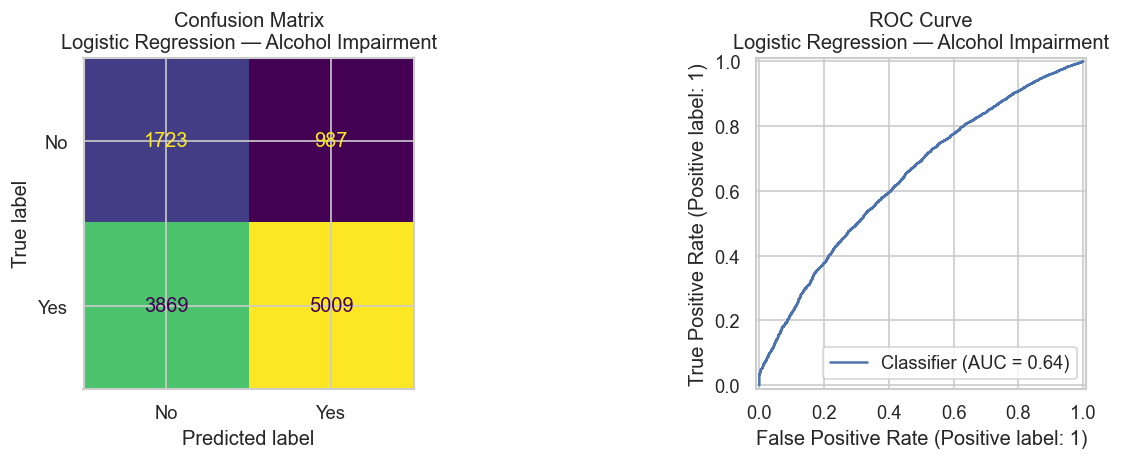

In [10]:
lr_alc = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    solver='lbfgs'
)
lr_alc.fit(X_alc_train, y_alc_train)
_ = evaluate_model(lr_alc, X_alc_test, y_alc_test, 'Logistic Regression', 'Alcohol Impairment')

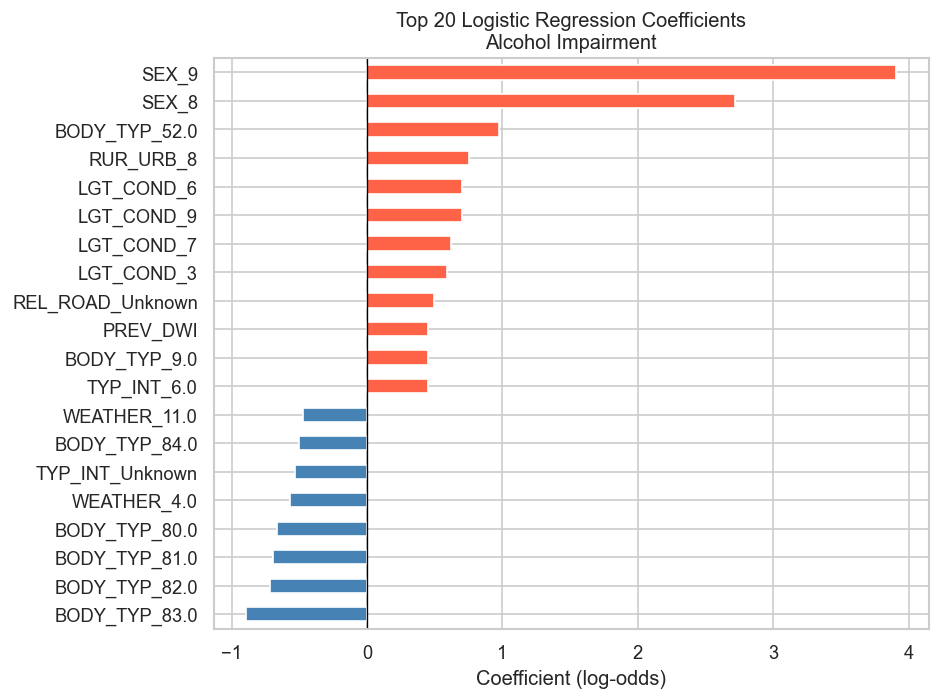

In [11]:
# Logistic regression coefficients (top 20 by absolute value)
coef_alc = pd.Series(lr_alc.coef_[0], index=feat_alc)
top_coef_alc = coef_alc.reindex(coef_alc.abs().nlargest(20).index).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in top_coef_alc]
top_coef_alc.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Logistic Regression Coefficients\nAlcohol Impairment')
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

### 5.2 Random Forest


══ Random Forest — Alcohol Impairment ══
              precision    recall  f1-score   support

          No       0.32      0.63      0.42      2710
         Yes       0.84      0.59      0.69      8878

    accuracy                           0.60     11588
   macro avg       0.58      0.61      0.56     11588
weighted avg       0.72      0.60      0.63     11588

ROC-AUC: 0.6493


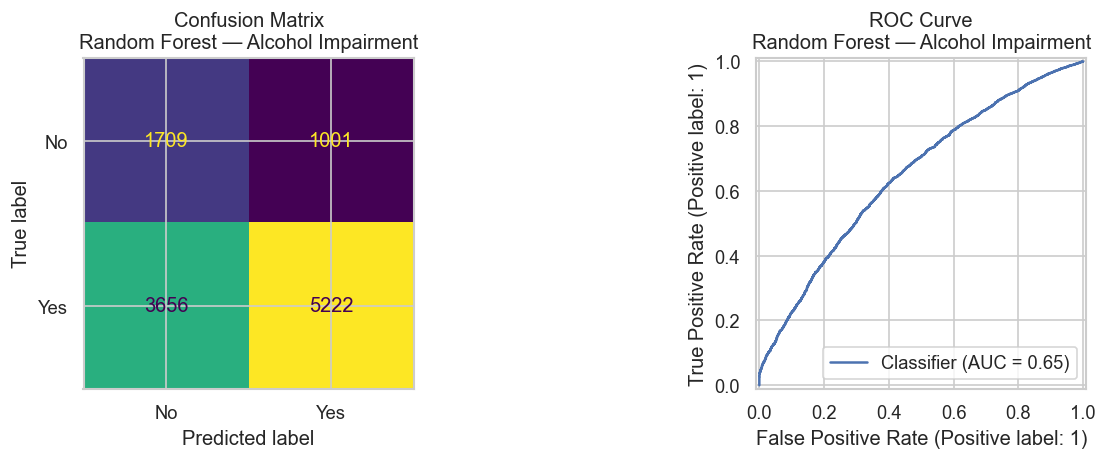

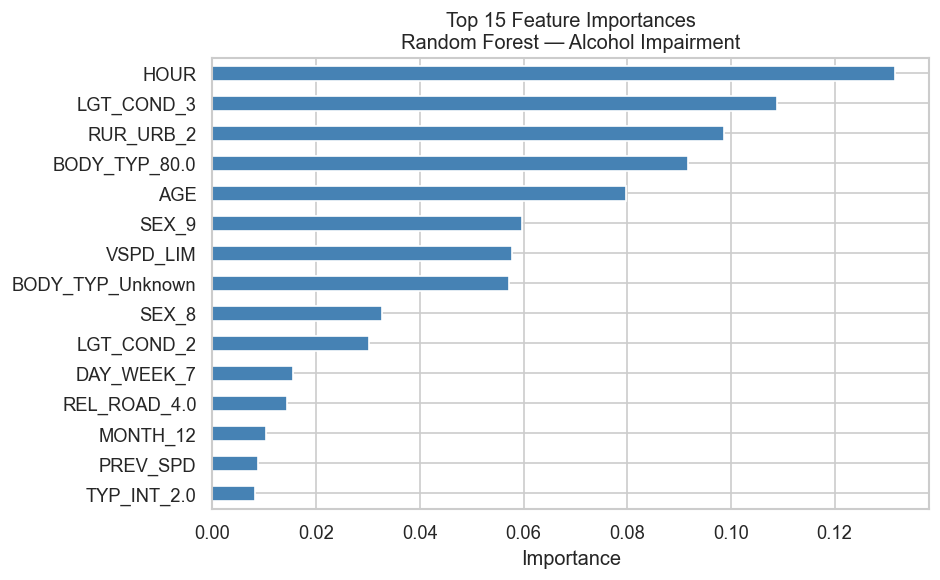

In [12]:
rf_alc = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_alc.fit(X_alc_train, y_alc_train)
_ = evaluate_model(rf_alc, X_alc_test, y_alc_test, 'Random Forest', 'Alcohol Impairment', feat_alc)

### 5.3 XGBoost

scale_pos_weight (alcohol): 0.31
[0]	validation_0-auc:0.62173
[100]	validation_0-auc:0.65405
[200]	validation_0-auc:0.65789
[300]	validation_0-auc:0.65796
[400]	validation_0-auc:0.65689
[499]	validation_0-auc:0.65548

══ XGBoost — Alcohol Impairment ══
              precision    recall  f1-score   support

          No       0.33      0.58      0.42      2710
         Yes       0.83      0.64      0.72      8878

    accuracy                           0.62     11588
   macro avg       0.58      0.61      0.57     11588
weighted avg       0.71      0.62      0.65     11588

ROC-AUC: 0.6555


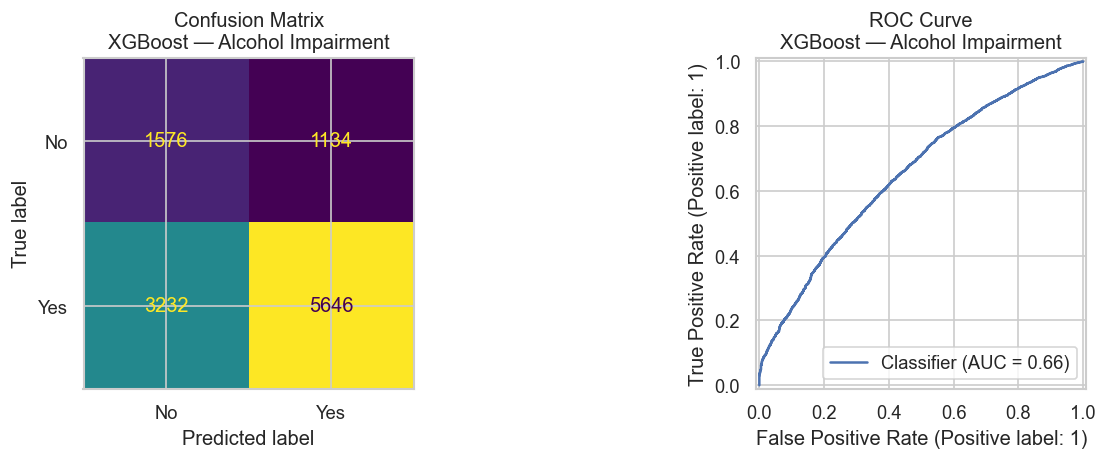

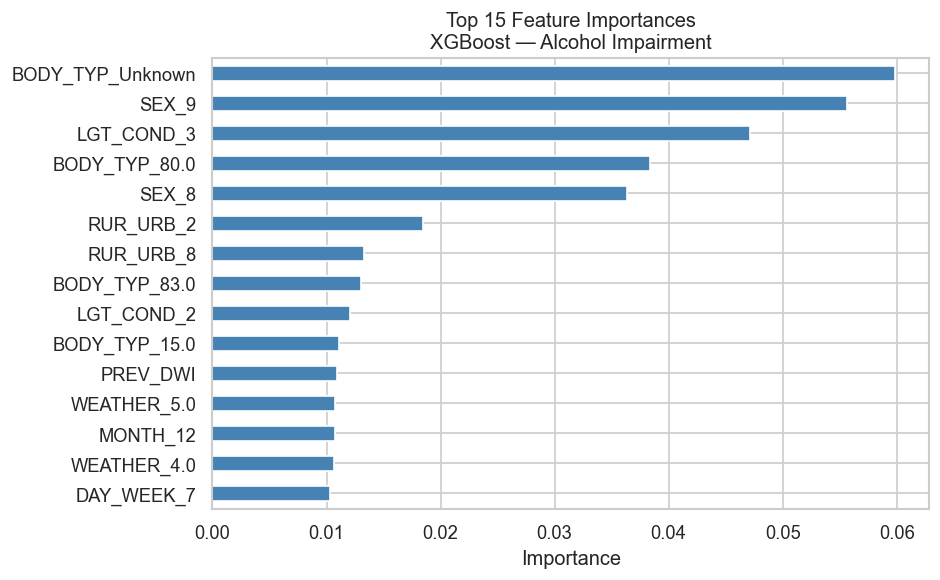

In [13]:
# scale_pos_weight handles class imbalance: ratio of negative to positive samples
neg_alc = (y_alc_train == 0).sum()
pos_alc = (y_alc_train == 1).sum()
spw_alc = neg_alc / pos_alc
print(f'scale_pos_weight (alcohol): {spw_alc:.2f}')

xgb_alc = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw_alc,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_alc.fit(
    X_alc_train, y_alc_train,
    eval_set=[(X_alc_test, y_alc_test)],
    verbose=100
)
_ = evaluate_model(xgb_alc, X_alc_test, y_alc_test, 'XGBoost', 'Alcohol Impairment', feat_alc)

### 5.4 SHAP Explainability — Alcohol Impairment (XGBoost)

SHAP Summary Plot — Alcohol Impairment


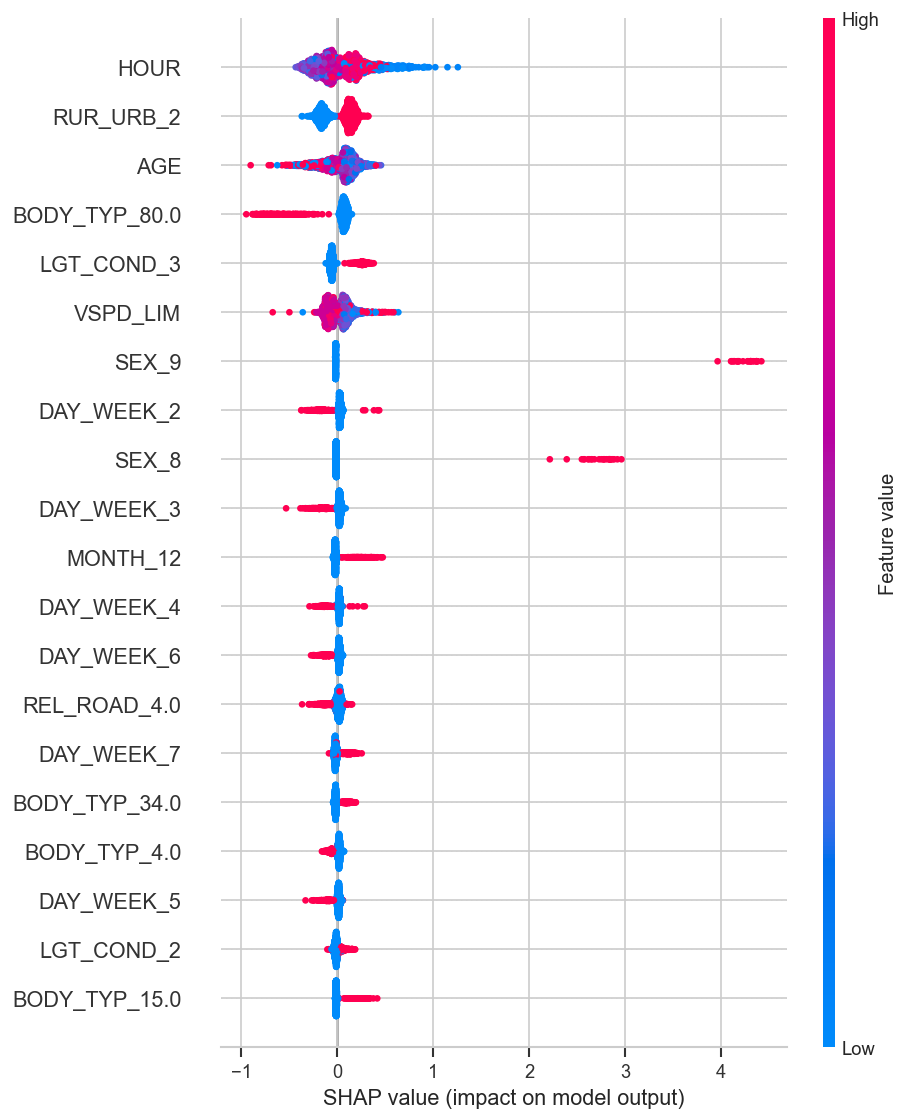

In [14]:
# Use a sample for SHAP speed (full test set can be slow)
shap_sample_alc = min(2000, X_alc_test.shape[0])
X_alc_shap = X_alc_test[:shap_sample_alc]

explainer_alc = shap.TreeExplainer(xgb_alc)
shap_values_alc = explainer_alc.shap_values(X_alc_shap)

print('SHAP Summary Plot — Alcohol Impairment')
shap.summary_plot(
    shap_values_alc, X_alc_shap,
    feature_names=feat_alc,
    max_display=20,
    show=True
)

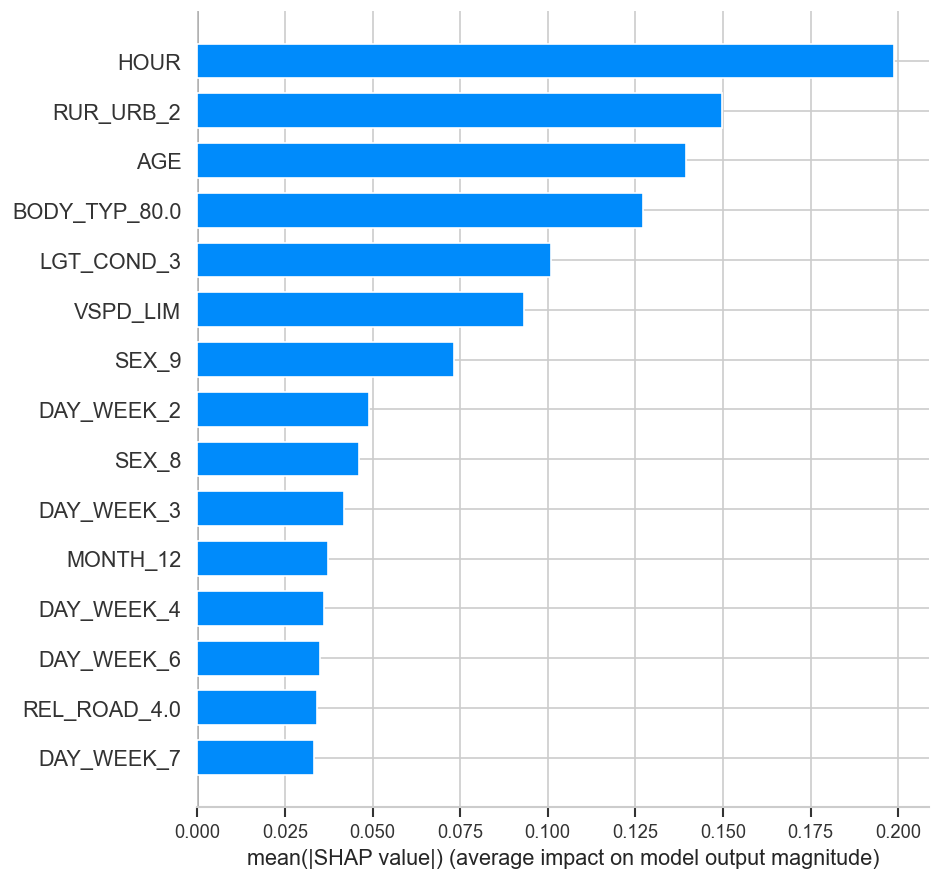

In [15]:
# SHAP bar plot (mean absolute impact)
shap.summary_plot(
    shap_values_alc, X_alc_shap,
    feature_names=feat_alc,
    plot_type='bar',
    max_display=15,
    show=True
)

### 5.5 Model Comparison — Alcohol Impairment

In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def model_comparison_table(models_dict, X_test, y_test):
    rows = []
    for name, model in models_dict.items():
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        rows.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_prob)
        })
    return pd.DataFrame(rows).set_index('Model').round(4)

alc_comparison = model_comparison_table(
    {'Logistic Regression': lr_alc, 'Random Forest': rf_alc, 'XGBoost': xgb_alc},
    X_alc_test, y_alc_test
)
print('=== Alcohol Impairment — Model Comparison ===')
alc_comparison

=== Alcohol Impairment — Model Comparison ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.5809,0.8354,0.5642,0.6735,0.6421
Random Forest,0.5981,0.8391,0.5882,0.6916,0.6493
XGBoost,0.6232,0.8327,0.6360,0.7212,0.6555


---
## 6. Speeding Models (RQ3 & RQ4)

**RQ3**: Are roadway design and environmental conditions associated with speeding-related fatal crashes?  
**RQ4**: How do speeding-related crash risk factors vary across states and roadway classifications?

> Note: `WRK_ZONE` is included here (RQ3-specific) but is excluded from the alcohol models.

### 6.1 Logistic Regression


══ Logistic Regression — Speeding ══
              precision    recall  f1-score   support

          No       0.92      0.75      0.83      8765
         Yes       0.42      0.72      0.53      2148

    accuracy                           0.75     10913
   macro avg       0.67      0.74      0.68     10913
weighted avg       0.82      0.75      0.77     10913

ROC-AUC: 0.8105


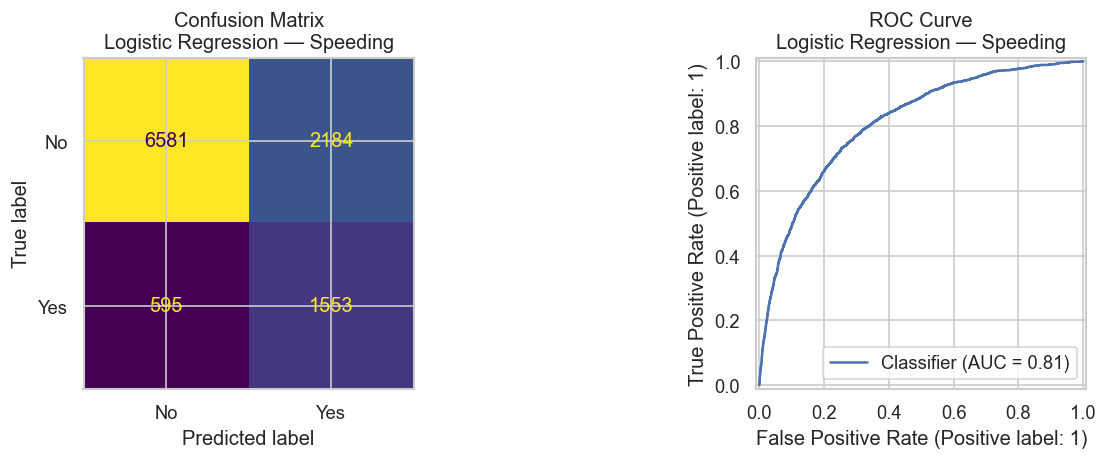

In [17]:
lr_spd = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    solver='lbfgs'
)
lr_spd.fit(X_spd_train, y_spd_train)
_ = evaluate_model(lr_spd, X_spd_test, y_spd_test, 'Logistic Regression', 'Speeding')

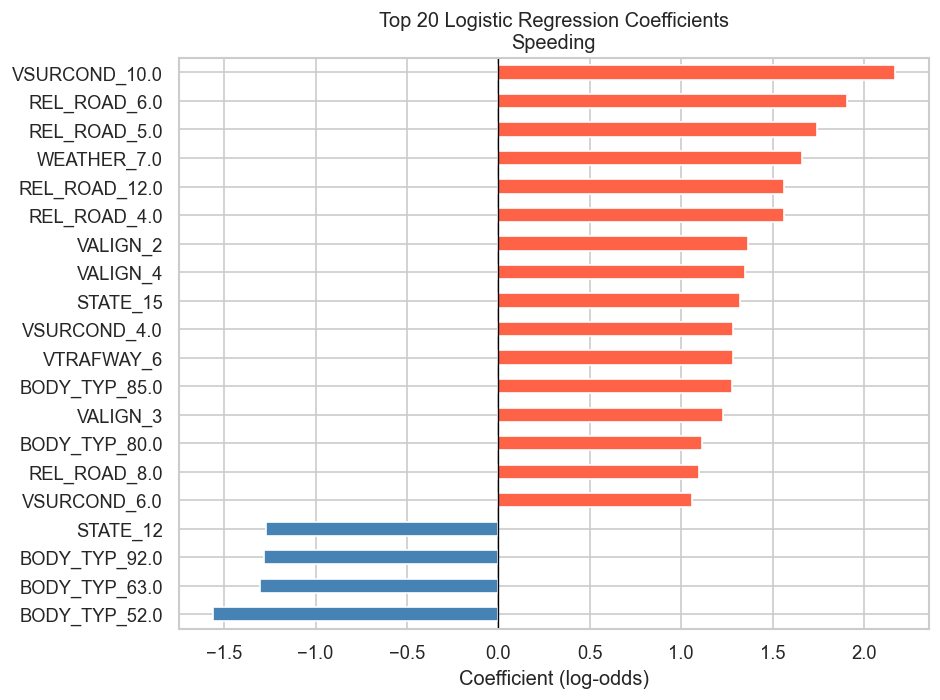

In [18]:
# Logistic regression coefficients (top 20)
coef_spd = pd.Series(lr_spd.coef_[0], index=feat_spd)
top_coef_spd = coef_spd.reindex(coef_spd.abs().nlargest(20).index).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in top_coef_spd]
top_coef_spd.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Logistic Regression Coefficients\nSpeeding')
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

### 6.2 Random Forest


══ Random Forest — Speeding ══
              precision    recall  f1-score   support

          No       0.91      0.78      0.84      8765
         Yes       0.43      0.67      0.53      2148

    accuracy                           0.76     10913
   macro avg       0.67      0.73      0.68     10913
weighted avg       0.81      0.76      0.78     10913

ROC-AUC: 0.8039


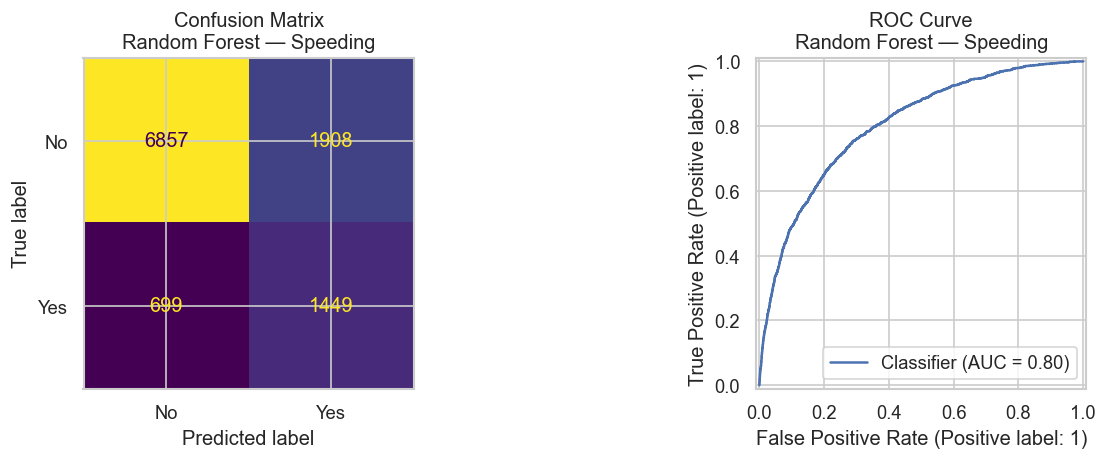

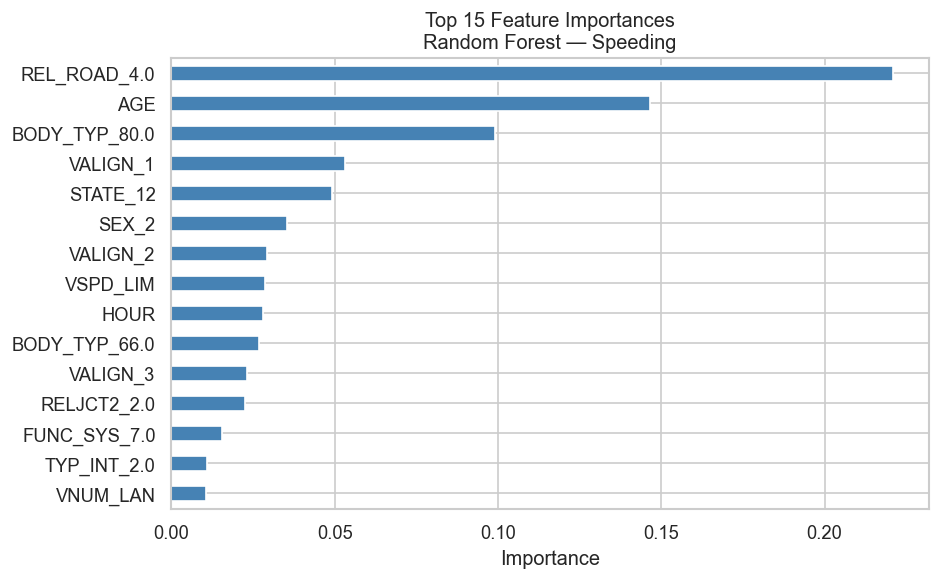

In [19]:
rf_spd = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_spd.fit(X_spd_train, y_spd_train)
_ = evaluate_model(rf_spd, X_spd_test, y_spd_test, 'Random Forest', 'Speeding', feat_spd)

### 6.3 XGBoost

scale_pos_weight (speeding): 4.08
[0]	validation_0-auc:0.76499
[100]	validation_0-auc:0.81380
[200]	validation_0-auc:0.81781
[300]	validation_0-auc:0.81959
[400]	validation_0-auc:0.81996
[499]	validation_0-auc:0.81964

══ XGBoost — Speeding ══
              precision    recall  f1-score   support

          No       0.91      0.79      0.85      8765
         Yes       0.45      0.69      0.54      2148

    accuracy                           0.77     10913
   macro avg       0.68      0.74      0.69     10913
weighted avg       0.82      0.77      0.79     10913

ROC-AUC: 0.8196


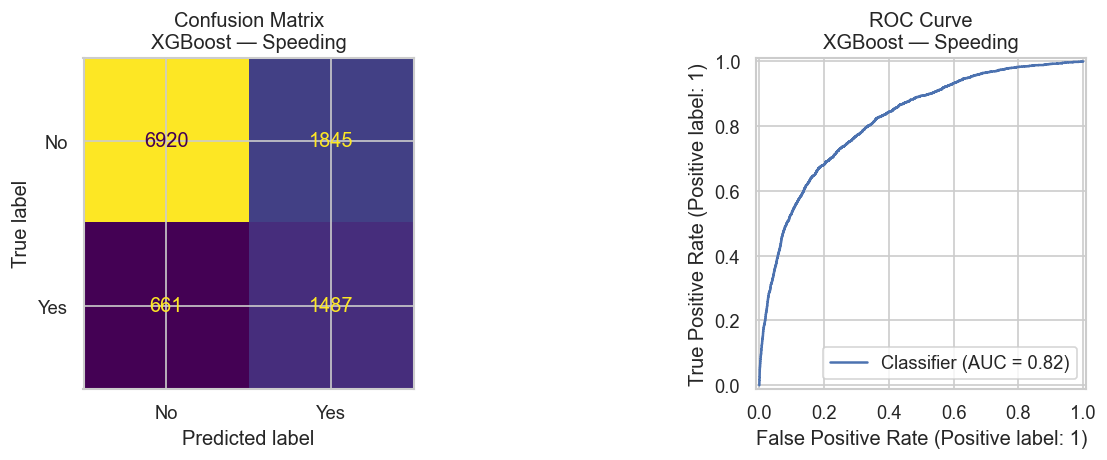

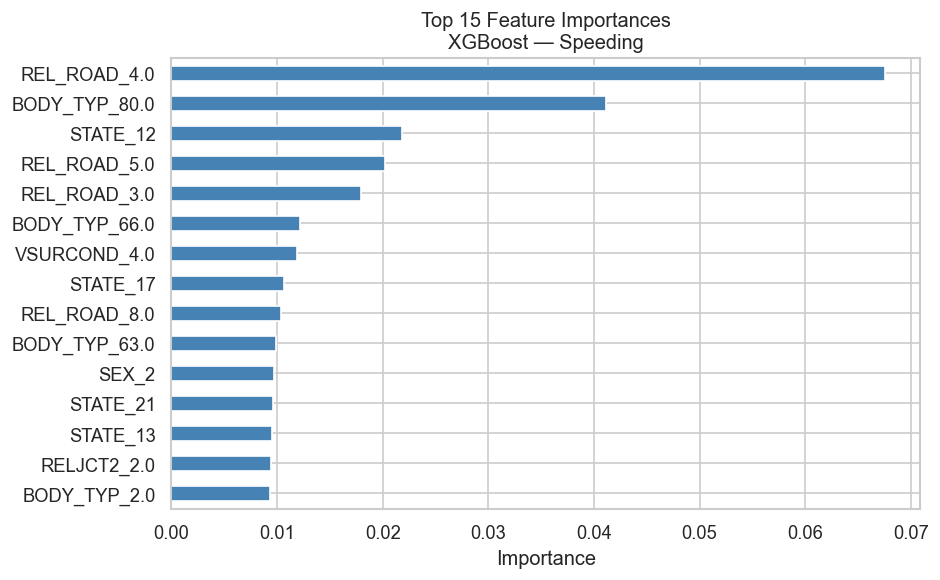

In [20]:
neg_spd = (y_spd_train == 0).sum()
pos_spd = (y_spd_train == 1).sum()
spw_spd = neg_spd / pos_spd
print(f'scale_pos_weight (speeding): {spw_spd:.2f}')

xgb_spd = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw_spd,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_spd.fit(
    X_spd_train, y_spd_train,
    eval_set=[(X_spd_test, y_spd_test)],
    verbose=100
)
_ = evaluate_model(xgb_spd, X_spd_test, y_spd_test, 'XGBoost', 'Speeding', feat_spd)

### 6.4 SHAP Explainability — Speeding (XGBoost)

SHAP Summary Plot — Speeding


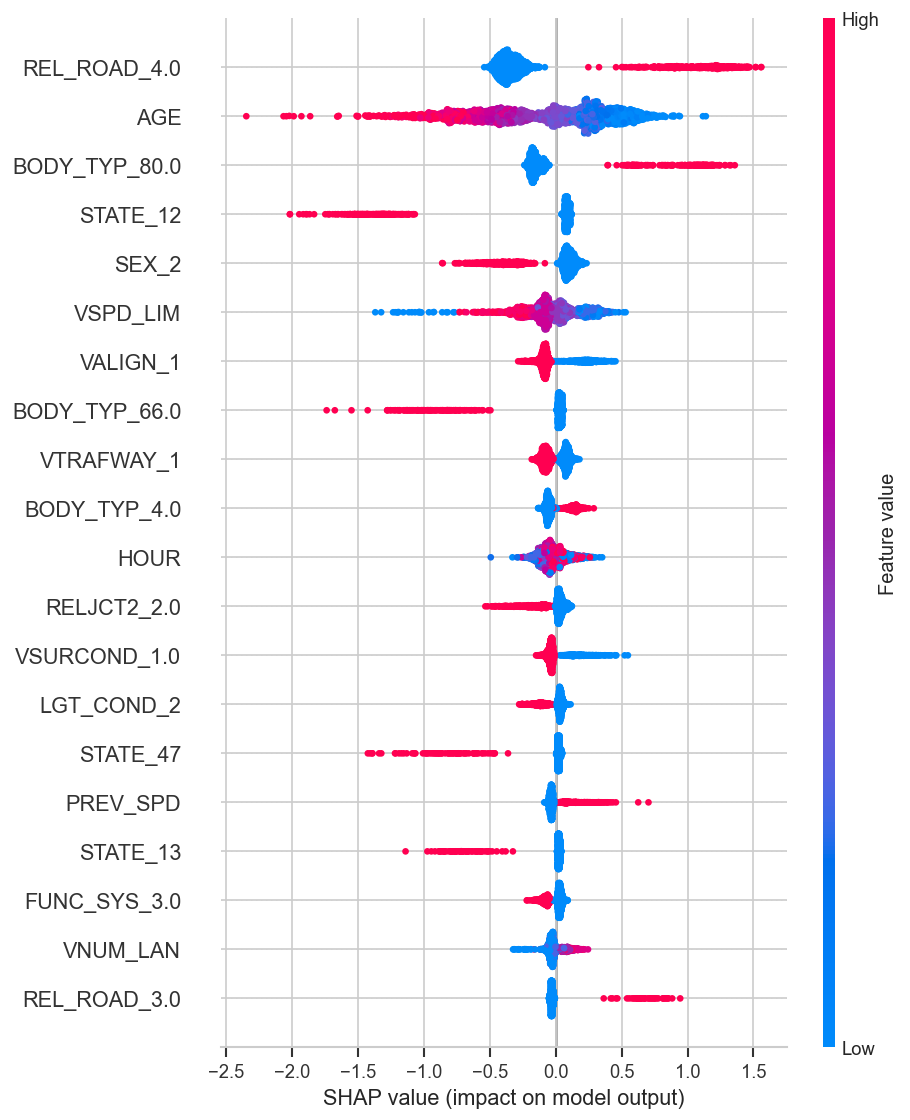

In [21]:
shap_sample_spd = min(2000, X_spd_test.shape[0])
X_spd_shap = X_spd_test[:shap_sample_spd]

explainer_spd = shap.TreeExplainer(xgb_spd)
shap_values_spd = explainer_spd.shap_values(X_spd_shap)

print('SHAP Summary Plot — Speeding')
shap.summary_plot(
    shap_values_spd, X_spd_shap,
    feature_names=feat_spd,
    max_display=20,
    show=True
)

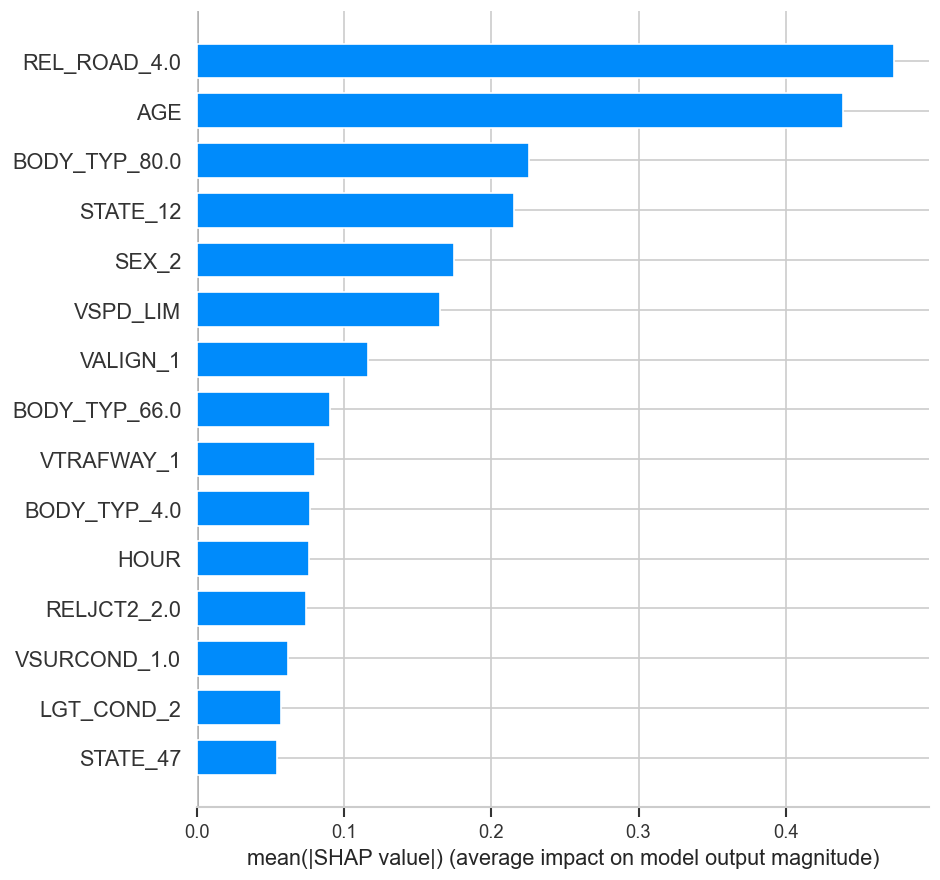

In [22]:
shap.summary_plot(
    shap_values_spd, X_spd_shap,
    feature_names=feat_spd,
    plot_type='bar',
    max_display=15,
    show=True
)

### 6.5 RQ4 — Geographic Analysis: Speeding Risk by State & Road Class

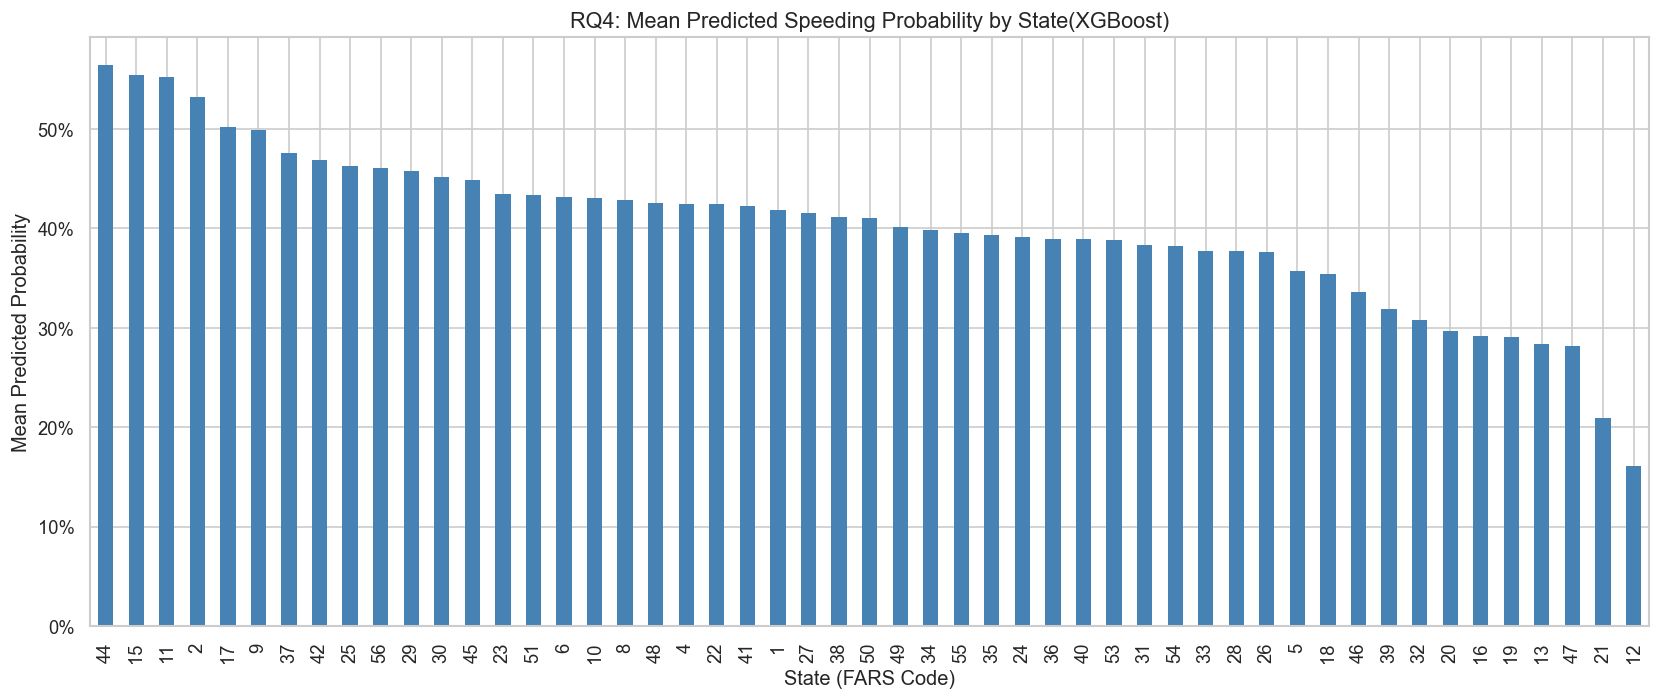

In [23]:
# Map XGBoost predictions back to original df rows via idx_spd
spd_geo = df.loc[idx_spd, ["STATE", "FUNC_SYS", "IS_SPEEDING"]].copy()
spd_geo["PRED_PROB"] = xgb_spd.predict_proba(X_spd)[:, 1]

# State-level average predicted speeding probability
state_risk = spd_geo.groupby("STATE")["PRED_PROB"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
state_risk.plot(kind="bar", ax=ax, color="steelblue", edgecolor="none")
ax.set_title("RQ4: Mean Predicted Speeding Probability by State(XGBoost)", fontsize=13)
ax.set_xlabel("State (FARS Code)")
ax.set_ylabel("Mean Predicted Probability")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

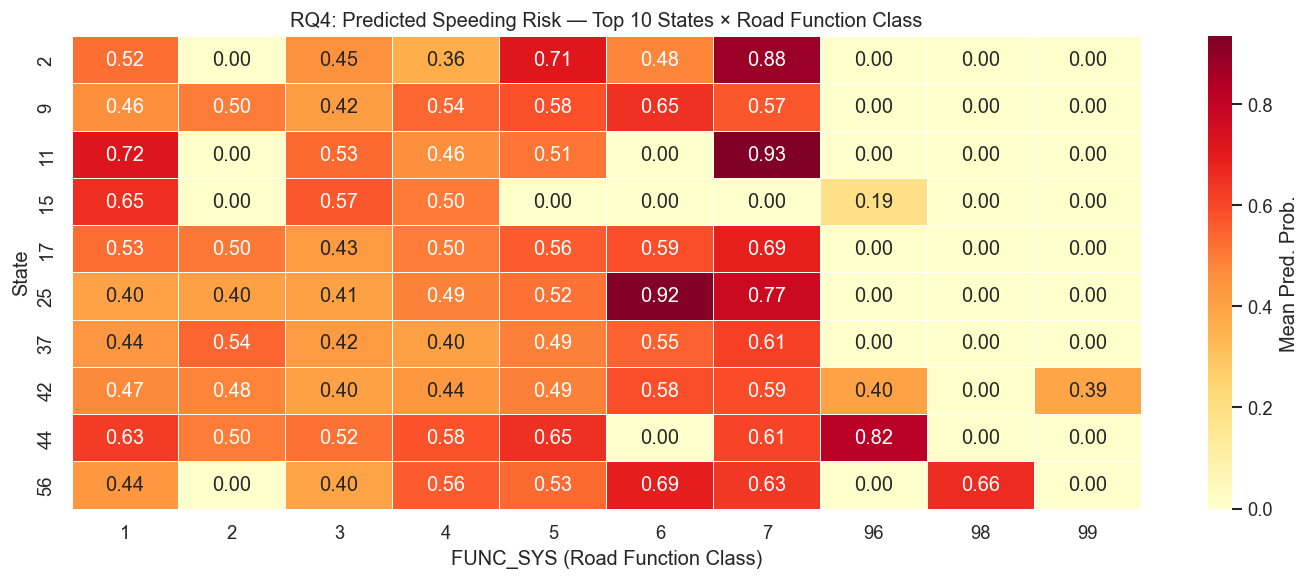

In [24]:
# Road class (FUNC_SYS) × speeding risk heatmap by state (top 10 states)
top_states = state_risk.head(10).index.tolist()
heat_data = (
    spd_geo[spd_geo['STATE'].isin(top_states)]
    .groupby(['STATE', 'FUNC_SYS'])['PRED_PROB']
    .mean()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heat_data, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean Pred. Prob.'}
)
ax.set_title('RQ4: Predicted Speeding Risk — Top 10 States × Road Function Class', fontsize=12)
ax.set_xlabel('FUNC_SYS (Road Function Class)')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

### 6.6 Model Comparison — Speeding

In [25]:
spd_comparison = model_comparison_table(
    {'Logistic Regression': lr_spd, 'Random Forest': rf_spd, 'XGBoost': xgb_spd},
    X_spd_test, y_spd_test
)
print('=== Speeding — Model Comparison ===')
spd_comparison

=== Speeding — Model Comparison ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.7453,0.4156,0.7230,0.5278,0.8105
Random Forest,0.7611,0.4316,0.6746,0.5264,0.8039
XGBoost,0.7704,0.4463,0.6923,0.5427,0.8196


---
## 7. Final Summary

| Target | Best Model (expected) | Key Metric to Report |
|---|---|---|
| Alcohol Impairment | XGBoost | ROC-AUC, F1, SHAP top features |
| Speeding | XGBoost | ROC-AUC, F1, SHAP top features, geographic heatmap |

**Findings to address per RQ:**
- **RQ1**: Logistic regression coefficients for age, sex, PREV_DWI vs. alcohol impairment
- **RQ2**: SHAP/RF importance ranking of temporal and environmental variables for alcohol
- **RQ3**: SHAP ranking of roadway design variables (incl. WRK_ZONE) for speeding
- **RQ4**: State × road class heatmap of predicted speeding risk